In [31]:
# Instalar mrmr-selection se não estiver instalado
# !pip install mrmr-selection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

# Seleção de features mRMR
try:
    from mrmr import mrmr_classif
    MRMR_AVAILABLE = True
except ImportError:
    MRMR_AVAILABLE = False
    print("⚠️ mRMR não está instalado. Instale com: pip install mrmr-selection")

# Sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import VarianceThreshold

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


In [2]:
# Carregar o dataset DoS
dos_path = Path("../data/processed/DoS_with_gap_features.csv")
df = pd.read_csv(dos_path)

print(f"📊 Shape do dataset: {df.shape}")
print(f"📝 Colunas: {df.shape[1]}")
print(f"📋 Registros: {df.shape[0]}")
print(f"\n🏷️ Distribuição do Label ('type'):")
print(df['type'].value_counts())

📊 Shape do dataset: (94625, 67)
📝 Colunas: 67
📋 Registros: 94625

🏷️ Distribuição do Label ('type'):
type
normal    49111
DoS       45514
Name: count, dtype: int64


In [4]:
# Selecionar apenas features numéricas
num_df = df.select_dtypes(include=['int64', 'float64'])

# Colunas a remover (irrelevantes para detecção de ataques)
colunas_para_remover = [
    'frame.time_delta_displayed', 'frame.time_epoch', 'frame.time_invalid', 
    'frame.time_relative', 'tcp.srcport', 'tcp.dstport', 
    'frame.coloring_rule.name', 'frame.coloring_rule.string', 
    'frame.comment', 'frame.comment.expert', 'frame.encap_type', 
    'frame.file_off', 'frame.ignored', 'frame.incomplete', 
    'frame.interface_id', 'frame.interface_name', 'frame.link_nr', 
    'frame.marked', 'frame.md5_hash', 'frame.number', 'frame.offset_shift',
    'mqtt.msgid', 'mqtt.username', 'mqtt.passwd', 
    'mqtt.willmsg', 'mqtt.willtopic'
]

# Remover colunas existentes no dataframe
colunas_existentes = [c for c in colunas_para_remover if c in num_df.columns]
X = num_df.drop(columns=colunas_existentes, errors='ignore')

# Tratar valores ausentes e infinitos
X = X.fillna(0)
X = X.replace([np.inf, -np.inf], 0)

# Encode do label (target)
le = LabelEncoder()
y = le.fit_transform(df['type'])

print(f"✅ Features numéricas após limpeza: {X.shape[1]}")
print(f"🎯 Classes: {le.classes_}")
print(f"📊 Shape X: {X.shape}, y: {y.shape}")

✅ Features numéricas após limpeza: 29
🎯 Classes: ['DoS' 'normal']
📊 Shape X: (94625, 29), y: (94625,)


In [6]:
X.describe()

,frame.time_delta,frame.cap_len,frame.len,mqtt.clientid_len,mqtt.conack.flags.reserved,mqtt.conack.flags.sp,mqtt.conack.val,mqtt.conflag.cleansess,mqtt.conflag.passwd,mqtt.conflag.qos,mqtt.conflag.reserved,mqtt.conflag.retain,mqtt.conflag.uname,mqtt.conflag.willflag,mqtt.dupflag,mqtt.kalive,mqtt.len,mqtt.msgtype,mqtt.passwd_len,mqtt.qos,mqtt.retain,mqtt.sub.qos,mqtt.suback.qos,mqtt.topic_len,mqtt.username_len,mqtt.willmsg_len,mqtt.willtopic_len,publish_gap,connect_gap
count,94625.000000,94625.000000,94625.000000,94625.000000,94625.000000,94625.000000,94625.000000,94625.000000,94625.0,94625.0,94625.0,94625.0,94625.0,94625.0,94625.000000,94625.000000,94625.000000,94625.000000,94625.0,94625.000000,94625.000000,94625.0,94625.0,94625.000000,94625.0,94625.0,94625.0,94625.000000,94625.000000
mean,0.012070,972.513828,972.513828,0.124756,0.004713,0.003065,0.403445,0.003413,0.0,0.0,0.0,0.0,0.0,0.0,0.001987,0.197675,65.932639,1.299741,0.0,0.012026,0.004196,0.0,0.0,166.283477,0.0,0.0,0.0,4.097958,1.374774
std,0.144073,663.725442,663.725442,2.144253,0.068492,0.055275,6.170456,0.058325,0.0,0.0,0.0,0.0,0.0,0.0,0.044529,3.422652,80.146643,1.689624,0.0,0.171537,0.064637,0.0,0.0,1614.081359,0.0,0.0,0.0,10.853330,3.045185
min,0.000000,38.000000,38.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000
25%,0.000062,77.000000,77.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000020
50%,0.000130,1514.000000,1514.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.194238,0.000020
75%,0.000781,1514.000000,1514.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,163.000000,3.000000,0.0,0.000000,0.000000,0.0,0.0,63.000000,0.0,0.0,0.0,2.425834,1.986573
max,5.628732,1514.000000,1514.000000,38.000000,1.000000,1.000000,116.000000,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,60.000000,182.000000,14.000000,0.0,3.000000,1.000000,0.0,0.0,29044.000000,0.0,0.0,0.0,57.168259,264.861559


In [7]:
if MRMR_AVAILABLE:
    K = 15 

x_mrmr = X.copy()
y_series = pd.Series(y, name ='target')

print(f"Executando mRMR para selecionar {K} features")

#Retornar a lista de features em ordem de importância 
selected_features = mrmr_classif(X=x_mrmr, y=y_series, K=K)

print(f" Top {K} Features por mRMR com o novo dataset:")
for i, feature in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feature}")


Executando mRMR para selecionar 15 features


100%|██████████| 15/15 [00:02<00:00,  6.07it/s]

 Top 15 Features por mRMR com o novo dataset:
   1. mqtt.len
   2. mqtt.dupflag
   3. mqtt.msgtype
   4. publish_gap
   5. frame.cap_len
   6. frame.len
   7. mqtt.kalive
   8. mqtt.topic_len
   9. frame.time_delta
  10. mqtt.qos
  11. mqtt.clientid_len
  12. mqtt.retain
  13. mqtt.conack.flags.reserved
  14. mqtt.conflag.cleansess
  15. mqtt.conack.val


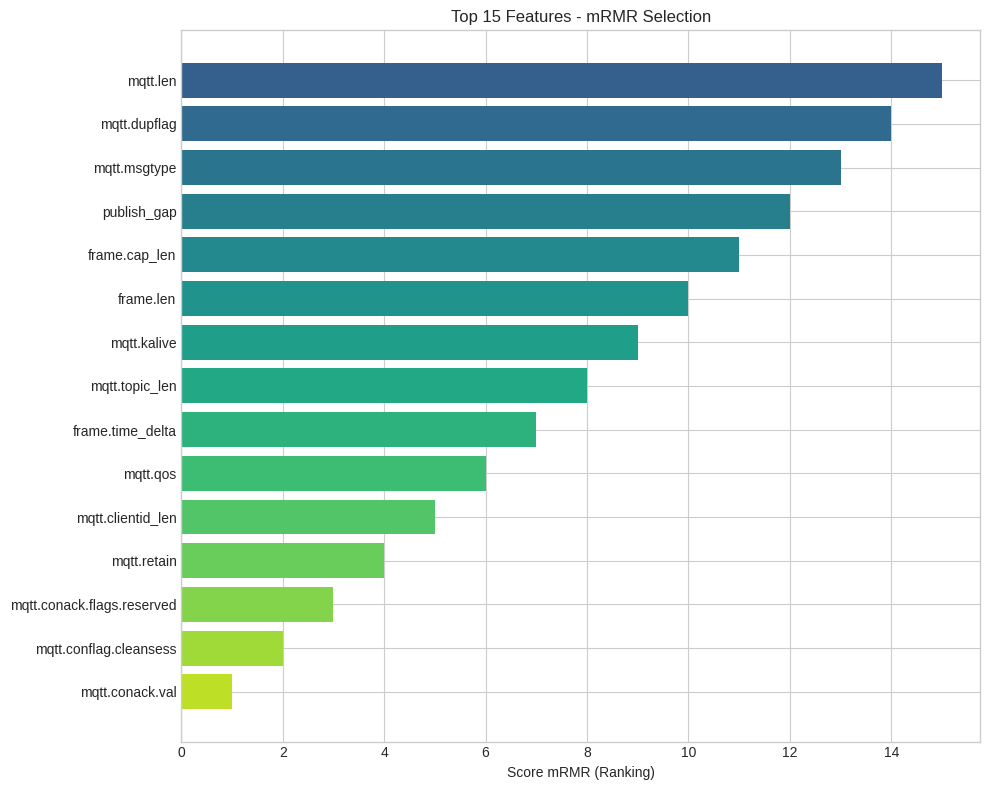

In [8]:
if selected_features:
    #Criar dataframe com ranking
    mrmr_ranking = pd.DataFrame({
        'rank': range(1, len(selected_features) + 1),
        'feature': selected_features
    })

#Plotar ranking
    fig, ax = plt.subplots(figsize=(10,8))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(selected_features)))
    
    bars = ax.barh(range(len(selected_features)), 
                   range(len(selected_features), 0, -1),
                   color=colors)
    
    ax.set_yticks(range(len(selected_features)))
    ax.set_yticklabels(selected_features)
    ax.set_xlabel('Score mRMR (Ranking)')
    ax.set_title(f'Top {len(selected_features)} Features - mRMR Selection', fontsize=12)
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

## 5. Seleção de Features via Fisher's Score

O **Fisher's Score** mede a capacidade discriminativa de cada feature, calculando a razão entre a variância inter-classes e a variância intra-classes. Features com alto Fisher's Score são melhores para separar as classes.

$$F(f) = \frac{\sum_{c=1}^{C} n_c (\mu_c - \mu)^2}{\sum_{c=1}^{C} n_c \sigma_c^2}$$

Onde:
- $\mu_c$ = média da feature na classe $c$
- $\sigma_c$ = desvio padrão da feature na classe $c$
- $\mu$ = média global da feature
- $n_c$ = número de amostras na classe $c$


In [9]:
def fisher_score(X, y):
    """
    Calcula o Fisher's Score para cada feature.
    
    Fisher's Score = variância inter-classes / variância intra-classes
    Features com maior score são mais discriminativas.
    """
    n_samples, n_features = X.shape
    classes = np.unique(y)
    n_classes = len(classes)
    
    # Média global de cada feature
    overall_mean = X.mean(axis=0)
    
    scores = np.zeros(n_features)
    
    for i in range(n_features):
        feature_values = X.iloc[:, i].values if hasattr(X, 'iloc') else X[:, i]
        
        # Variância inter-classes 
        between_class_var = 0
        # Variância intra-classes 
        within_class_var = 0
        
        for c in classes:
            class_mask = (y == c)
            n_c = np.sum(class_mask)
            
            if n_c > 0:
                class_mean = feature_values[class_mask].mean()
                class_var = feature_values[class_mask].var()
                
                between_class_var += n_c * (class_mean - overall_mean.iloc[i]) ** 2
                within_class_var += n_c * class_var
        
        # Evitar divisão por zero
        if within_class_var > 1e-10:
            scores[i] = between_class_var / within_class_var
        else:
            scores[i] = 0
    
    return scores

# Calcular Fisher's Score
print("🔍 Calculando Fisher's Score para cada feature...")
fisher_scores = fisher_score(X, y)

# Criar DataFrame com resultados
fisher_df = pd.DataFrame({
    'feature': X.columns,
    'fisher_score': fisher_scores
}).sort_values('fisher_score', ascending=False)

# Selecionar top K features no caso 15
K_fisher = 15
fisher_selected = fisher_df.head(K_fisher)['feature'].tolist()

print(f"\n🏆 Top {K_fisher} Features por Fisher's Score:")
for i, (_, row) in enumerate(fisher_df.head(K_fisher).iterrows(), 1):
    print(f"  {i:2d}. {row['feature']}: {row['fisher_score']:.4f}")

🔍 Calculando Fisher's Score para cada feature...

🏆 Top 15 Features por Fisher's Score:
   1. mqtt.len: 2.6804
   2. mqtt.msgtype: 1.3216
   3. publish_gap: 0.1497
   4. frame.len: 0.0974
   5. frame.cap_len: 0.0974
   6. mqtt.topic_len: 0.0116
   7. mqtt.qos: 0.0053
   8. mqtt.conack.flags.reserved: 0.0051
   9. mqtt.conack.val: 0.0046
  10. mqtt.retain: 0.0046
  11. mqtt.kalive: 0.0035
  12. mqtt.clientid_len: 0.0034
  13. mqtt.conack.flags.sp: 0.0033
  14. mqtt.conflag.cleansess: 0.0033
  15. mqtt.dupflag: 0.0022


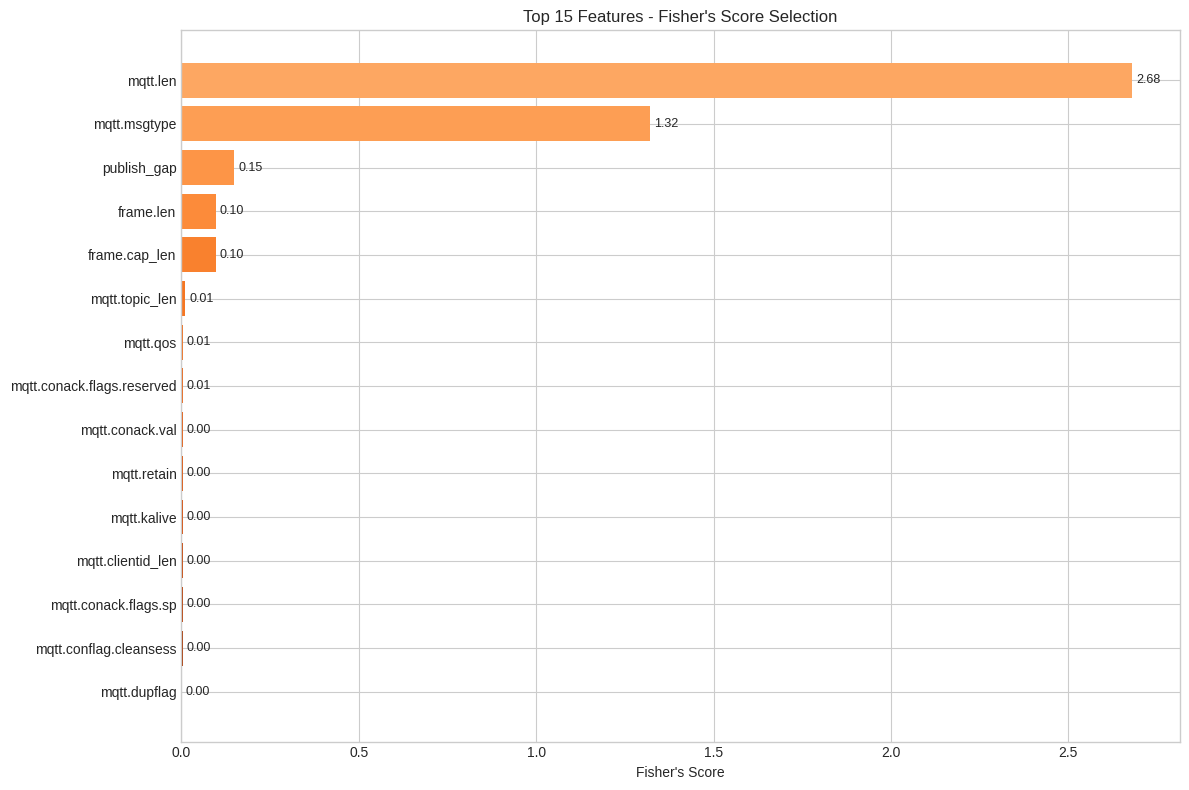

In [10]:
# Visualizar Fisher's Score
fig, ax = plt.subplots(figsize=(12, 8))

top_fisher = fisher_df.head(K_fisher)
colors = plt.cm.Oranges(np.linspace(0.4, 0.9, K_fisher))

bars = ax.barh(range(K_fisher), top_fisher['fisher_score'].values, color=colors)
ax.set_yticks(range(K_fisher))
ax.set_yticklabels(top_fisher['feature'].values)
ax.set_xlabel("Fisher's Score")
ax.set_title(f"Top {K_fisher} Features - Fisher's Score Selection", fontsize=12)
ax.invert_yaxis()

# Adicionar valores nas barras
for i, (bar, score) in enumerate(zip(bars, top_fisher['fisher_score'].values)):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Seleção de Features via Correlação de Pearson

A **Correlação de Pearson** mede a relação linear entre cada feature e o target. Features com alta correlação absoluta (|r| próximo de 1) são mais relevantes para predição.

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

**Nota**: Usamos o valor absoluto da correlação, pois tanto correlações positivas fortes quanto negativas fortes são úteis para classificação.

In [11]:
from scipy.stats import pearsonr

def pearson_correlation_with_target(X, y):
    """
    Calcula a correlação de Pearson entre cada feature e o target.
    Retorna o valor absoluto da correlação e o p-value.
    """
    n_features = X.shape[1]
    correlations = np.zeros(n_features)
    p_values = np.zeros(n_features)
    
    for i in range(n_features):
        feature_values = X.iloc[:, i].values if hasattr(X, 'iloc') else X[:, i]
        
        # Calcular correlação de Pearson
        corr, p_val = pearsonr(feature_values, y)
        correlations[i] = corr
        p_values[i] = p_val
    
    return correlations, p_values

# Calcular correlação de Pearson
print("🔍 Calculando Correlação de Pearson entre features e target...")
pearson_corrs, pearson_pvals = pearson_correlation_with_target(X, y)

#Criar dataframe com os resultados
pearson_df = pd.DataFrame({
    'feature': X.columns,
    'pearson_corr': pearson_corrs,
    'abs_corr': np.abs(pearson_corrs),
    'p_value': pearson_pvals
}).sort_values('abs_corr', ascending=False)

#Selecionar as top K features
K_pearson = 15
pearson_selected = pearson_df.head(K_pearson)['feature'].tolist()
print(f"\n🏆 Top {K_pearson} Features por Correlação de Pearson (|r|):")
for i, (_, row) in enumerate(pearson_df.head(K_pearson).iterrows(), 1):
    sig = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
    print(f"  {i:2d}. {row['feature']}: r={row['pearson_corr']:.4f} (|r|={row['abs_corr']:.4f}) {sig}")

print("\n📝 Legenda: *** p<0.001, ** p<0.01, * p<0.05")

🔍 Calculando Correlação de Pearson entre features e target...

🏆 Top 15 Features por Correlação de Pearson (|r|):
   1. mqtt.len: r=-0.8534 (|r|=0.8534) ***
   2. mqtt.msgtype: r=-0.7545 (|r|=0.7545) ***
   3. publish_gap: r=0.3609 (|r|=0.3609) ***
   4. frame.len: r=-0.2979 (|r|=0.2979) ***
   5. frame.cap_len: r=-0.2979 (|r|=0.2979) ***
   6. mqtt.topic_len: r=-0.1070 (|r|=0.1070) ***
   7. mqtt.qos: r=-0.0728 (|r|=0.0728) ***
   8. mqtt.conack.flags.reserved: r=-0.0715 (|r|=0.0715) ***
   9. mqtt.conack.val: r=-0.0679 (|r|=0.0679) ***
  10. mqtt.retain: r=-0.0674 (|r|=0.0674) ***
  11. mqtt.kalive: r=-0.0591 (|r|=0.0591) ***
  12. mqtt.clientid_len: r=-0.0583 (|r|=0.0583) ***
  13. mqtt.conack.flags.sp: r=-0.0576 (|r|=0.0576) ***
  14. mqtt.conflag.cleansess: r=-0.0572 (|r|=0.0572) ***
  15. mqtt.dupflag: r=-0.0463 (|r|=0.0463) ***

📝 Legenda: *** p<0.001, ** p<0.01, * p<0.05


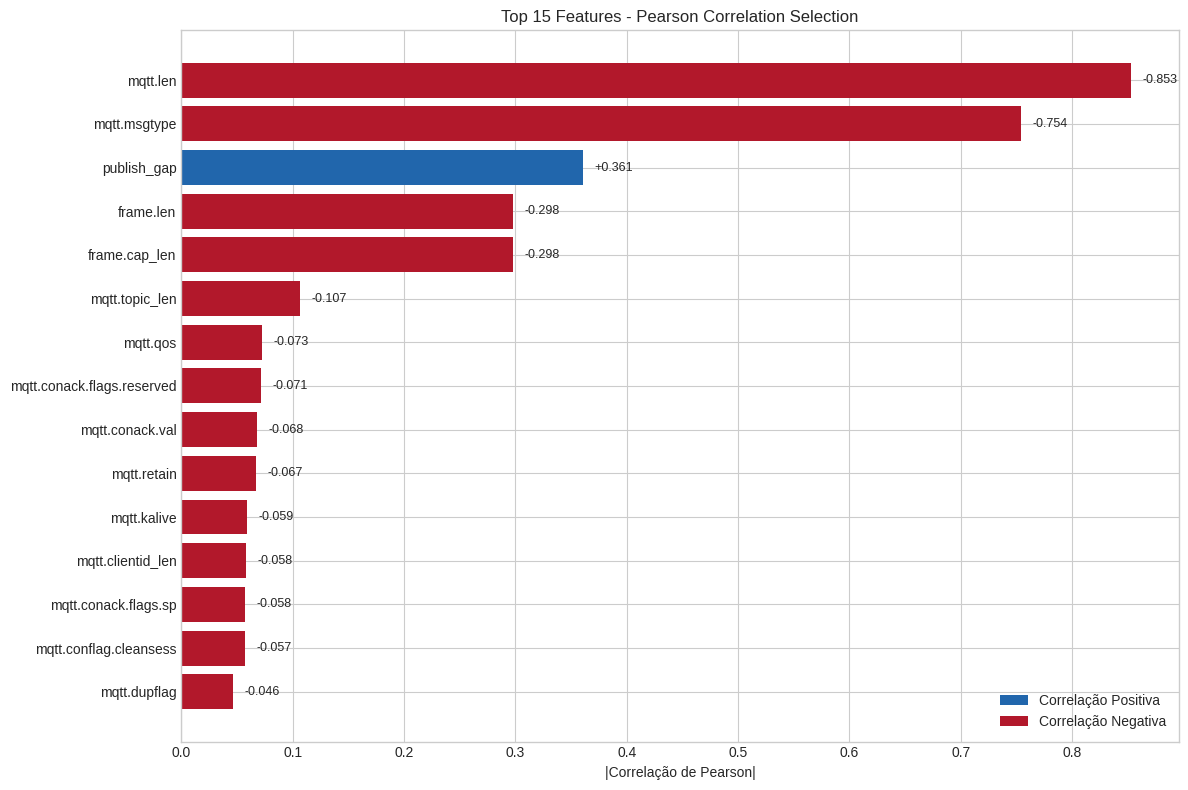

In [12]:
# Visualizar Correlação de Pearson
fig, ax = plt.subplots(figsize=(12, 8))

top_pearson = pearson_df.head(K_pearson)

# Cores baseadas no sinal da correlação (positiva=azul, negativa=vermelho)
colors = ['#2166ac' if c > 0 else '#b2182b' for c in top_pearson['pearson_corr'].values]

bars = ax.barh(range(K_pearson), top_pearson['abs_corr'].values, color=colors)
ax.set_yticks(range(K_pearson))
ax.set_yticklabels(top_pearson['feature'].values)
ax.set_xlabel('|Correlação de Pearson|')
ax.set_title(f'Top {K_pearson} Features - Pearson Correlation Selection', fontsize=12)
ax.invert_yaxis()

# Adicionar valores nas barras
for i, (bar, corr, abs_corr) in enumerate(zip(bars, top_pearson['pearson_corr'].values, top_pearson['abs_corr'].values)):
    sign = '+' if corr > 0 else '-'
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{sign}{abs_corr:.3f}', va='center', fontsize=9)

# Legenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2166ac', label='Correlação Positiva'),
                   Patch(facecolor='#b2182b', label='Correlação Negativa')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# Comparação dos métodos até agora

In [14]:
# Comparar features selecionadas pelos métodos disponíveis
print("📊 COMPARAÇÃO DOS MÉTODOS DE SELEÇÃO DE FEATURES")
print("=" * 60)

# Criar conjuntos de features
set_mrmr = set(selected_features) if selected_features else set()
set_fisher = set(fisher_selected)
set_pearson = set(pearson_selected)

# Features em comum
common_all = set_mrmr & set_fisher & set_pearson
common_mrmr_fisher = set_mrmr & set_fisher
common_mrmr_pearson = set_mrmr & set_pearson
common_fisher_pearson = set_fisher & set_pearson

print(f"\n🔹 mRMR selecionou: {len(set_mrmr)} features")
print(f"🔹 Fisher's Score selecionou: {len(set_fisher)} features")
print(f"🔹 Pearson selecionou: {len(set_pearson)} features")

print(f"\n📌 Features em comum (mRMR ∩ Fisher ∩ Pearson): {len(common_all)}")
if common_all:
    for f in common_all:
        print(f"   - {f}")

print(f"\n📌 Interseções par-a-par:")
print(f"   mRMR ∩ Fisher: {len(common_mrmr_fisher)}")
print(f"   mRMR ∩ Pearson: {len(common_mrmr_pearson)}")
print(f"   Fisher ∩ Pearson: {len(common_fisher_pearson)}")

📊 COMPARAÇÃO DOS MÉTODOS DE SELEÇÃO DE FEATURES

🔹 mRMR selecionou: 15 features
🔹 Fisher's Score selecionou: 15 features
🔹 Pearson selecionou: 15 features

📌 Features em comum (mRMR ∩ Fisher ∩ Pearson): 14
   - mqtt.conflag.cleansess
   - mqtt.msgtype
   - mqtt.dupflag
   - mqtt.topic_len
   - mqtt.retain
   - publish_gap
   - mqtt.len
   - frame.cap_len
   - mqtt.clientid_len
   - mqtt.conack.flags.reserved
   - mqtt.conack.val
   - mqtt.kalive
   - mqtt.qos
   - frame.len

📌 Interseções par-a-par:
   mRMR ∩ Fisher: 14
   mRMR ∩ Pearson: 14
   Fisher ∩ Pearson: 15


In [16]:
# Criar tabela comparativa de rankings (incluindo ExtraTrees se disponível)
comparison_df = pd.DataFrame({
    'feature': X.columns
})

# Adicionar rankings de cada método
if selected_features:
    mrmr_rank = {f: i+1 for i, f in enumerate(selected_features)}
    comparison_df['mrmr_rank'] = comparison_df['feature'].map(lambda x: mrmr_rank.get(x, None))

fisher_rank = {row['feature']: i+1 for i, (_, row) in enumerate(fisher_df.iterrows())}
comparison_df['fisher_rank'] = comparison_df['feature'].map(lambda x: fisher_rank.get(x, None))

pearson_rank = {row['feature']: i+1 for i, (_, row) in enumerate(pearson_df.iterrows())}
comparison_df['pearson_rank'] = comparison_df['feature'].map(lambda x: pearson_rank.get(x, None))

# Adicionar ExtraTrees se disponível
try:
    extratree_rank = {row['feature']: i+1 for i, (_, row) in enumerate(extratree_df.iterrows())}
    comparison_df['extratree_rank'] = comparison_df['feature'].map(lambda x: extratree_rank.get(x, None))
    rank_cols = ['mrmr_rank', 'fisher_rank', 'pearson_rank', 'extratree_rank']
except:
    rank_cols = ['mrmr_rank', 'fisher_rank', 'pearson_rank']

# Filtrar apenas features que aparecem no top K de pelo menos um método
try:
    top_features = set_mrmr | set_fisher | set_pearson | set_extratree
except:
    top_features = set_mrmr | set_fisher | set_pearson
    
comparison_top = comparison_df[comparison_df['feature'].isin(top_features)].copy()

# Ordenar por média dos rankings (menor = melhor)
comparison_top['mean_rank'] = comparison_top[rank_cols].mean(axis=1, skipna=True)
comparison_top = comparison_top.sort_values('mean_rank')

print("📊 Ranking Comparativo das Features Selecionadas:")
print("=" * 80)
print(comparison_top.head(20).to_string(index=False))

📊 Ranking Comparativo das Features Selecionadas:
                   feature  mrmr_rank  fisher_rank  pearson_rank  mean_rank
                  mqtt.len        1.0            1             1   1.000000
              mqtt.msgtype        3.0            2             2   2.333333
               publish_gap        4.0            3             3   3.333333
                 frame.len        6.0            4             4   4.666667
             frame.cap_len        5.0            5             5   5.000000
            mqtt.topic_len        8.0            6             6   6.666667
                  mqtt.qos       10.0            7             7   8.000000
mqtt.conack.flags.reserved       13.0            8             8   9.666667
               mqtt.kalive        7.0           11            11   9.666667
              mqtt.dupflag        2.0           15            15  10.666667
               mqtt.retain       12.0           10            10  10.666667
           mqtt.conack.val       15.0  

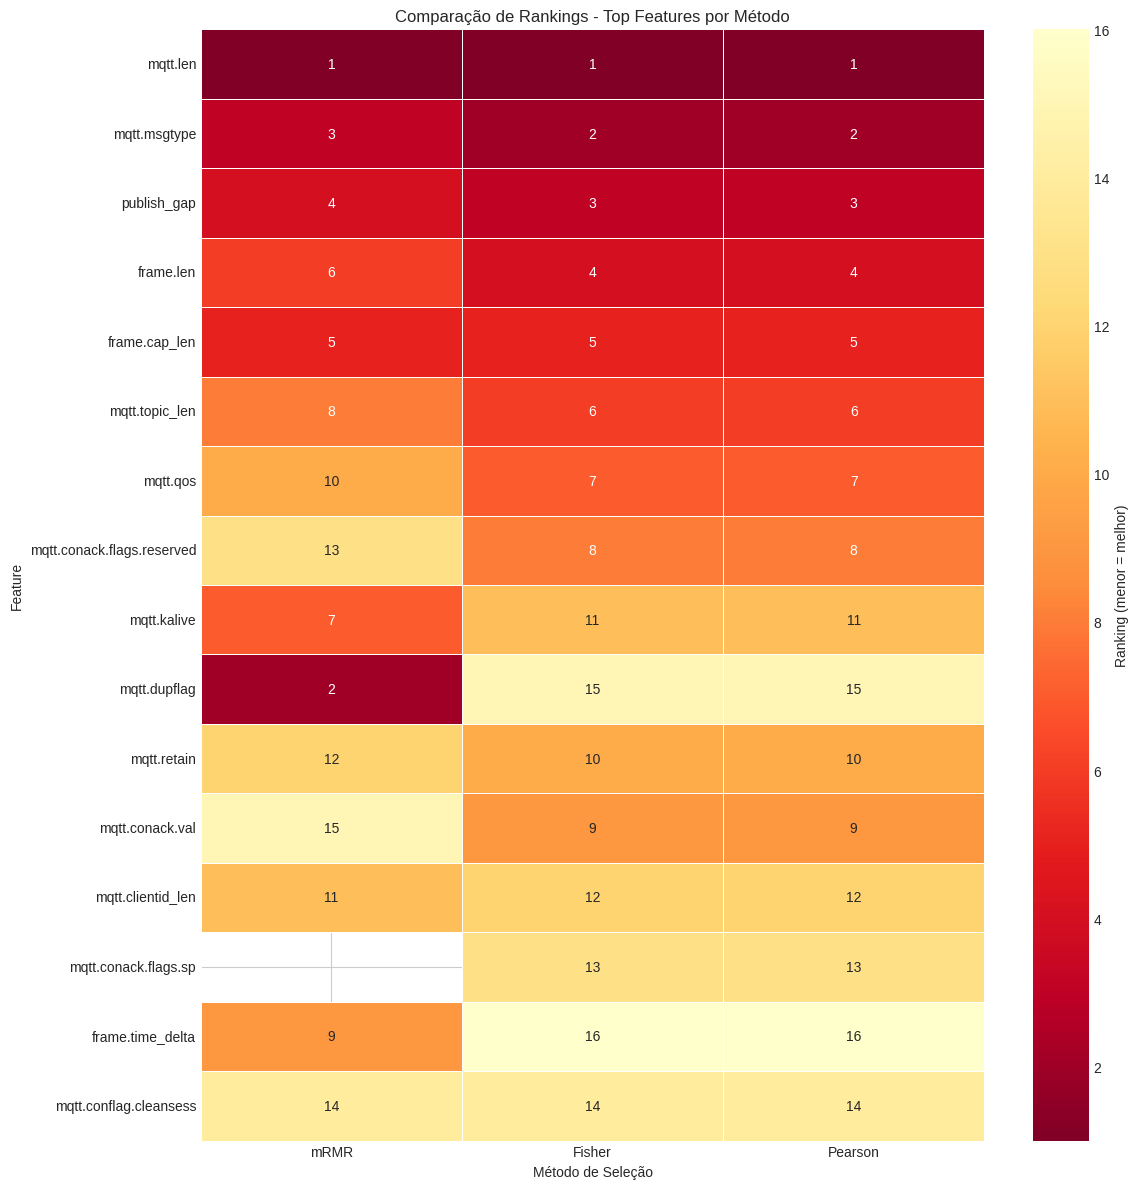

In [17]:
# Visualização: Heatmap de rankings (incluindo ExtraTrees)
fig, ax = plt.subplots(figsize=(12, 12))

# Preparar dados para heatmap
try:
    heatmap_data = comparison_top.head(20).set_index('feature')[['mrmr_rank', 'fisher_rank', 'pearson_rank', 'extratree_rank']]
    heatmap_data.columns = ['mRMR', 'Fisher', 'Pearson', 'ExtraTrees']
except:
    heatmap_data = comparison_top.head(20).set_index('feature')[['mrmr_rank', 'fisher_rank', 'pearson_rank']]
    heatmap_data.columns = ['mRMR', 'Fisher', 'Pearson']

# Substituir None por NaN para visualização
heatmap_data = heatmap_data.fillna(np.nan)

# Criar heatmap
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.0f',
            cmap='YlOrRd_r',
            cbar_kws={'label': 'Ranking (menor = melhor)'},
            linewidths=0.5,
            ax=ax,
            mask=heatmap_data.isna())

ax.set_title('Comparação de Rankings - Top Features por Método', fontsize=12)
ax.set_xlabel('Método de Seleção')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()

# Seleção via low variance

In [18]:
# Para variância menor que 0.05
threshold = 0.05

selector = VarianceThreshold(threshold=threshold)
X_reduced = selector.fit_transform(X)

features_mantidas = X.columns[selector.get_support()].tolist()
features_removidas = X.columns[~selector.get_support()].tolist()

print(f"🔹 Features originais: {X.shape[1]}")
print(f"🔹 Features mantidas: {len(features_mantidas)}")
print(f"🔹 Features removidas: {len(features_removidas)}")


print(f"\n Features Mantidas:")
for i, f in enumerate(features_mantidas, 1):
    print(f"  {i:2d}. {f}")

print(f"\n❌ Features Removidas (variância < {threshold}):")
for i, f in enumerate(features_removidas, 1):
    print(f"  {i:2d}. {f}")

🔹 Features originais: 29
🔹 Features mantidas: 10
🔹 Features removidas: 19

 Features Mantidas:
   1. frame.cap_len
   2. frame.len
   3. mqtt.clientid_len
   4. mqtt.conack.val
   5. mqtt.kalive
   6. mqtt.len
   7. mqtt.msgtype
   8. mqtt.topic_len
   9. publish_gap
  10. connect_gap

❌ Features Removidas (variância < 0.05):
   1. frame.time_delta
   2. mqtt.conack.flags.reserved
   3. mqtt.conack.flags.sp
   4. mqtt.conflag.cleansess
   5. mqtt.conflag.passwd
   6. mqtt.conflag.qos
   7. mqtt.conflag.reserved
   8. mqtt.conflag.retain
   9. mqtt.conflag.uname
  10. mqtt.conflag.willflag
  11. mqtt.dupflag
  12. mqtt.passwd_len
  13. mqtt.qos
  14. mqtt.retain
  15. mqtt.sub.qos
  16. mqtt.suback.qos
  17. mqtt.username_len
  18. mqtt.willmsg_len
  19. mqtt.willtopic_len


# Seleção via ExtraTrees 

In [19]:
extra_tree = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs =-1)
extra_tree.fit(X,y)

importances = extra_tree.feature_importances_

extratree_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances

}).sort_values('importance', ascending=False)

K_tree = 15
extratree_selected = extratree_df.head(K_tree)['feature'].tolist()

print(f"\n Top {K_tree} Features por ExtraTreesClassifier:")
for i, (_, row) in enumerate(extratree_df.head(K_tree).iterrows(), 1):
    print(f"  {i:2d}. {row['feature']}: {row['importance']:.4f}")


 Top 15 Features por ExtraTreesClassifier:
   1. mqtt.len: 0.3841
   2. mqtt.msgtype: 0.1843
   3. publish_gap: 0.1758
   4. frame.cap_len: 0.0700
   5. mqtt.topic_len: 0.0672
   6. frame.len: 0.0639
   7. connect_gap: 0.0328
   8. frame.time_delta: 0.0124
   9. mqtt.kalive: 0.0022
  10. mqtt.clientid_len: 0.0016
  11. mqtt.conflag.cleansess: 0.0013
  12. mqtt.conack.flags.reserved: 0.0013
  13. mqtt.qos: 0.0011
  14. mqtt.conack.val: 0.0008
  15. mqtt.retain: 0.0007


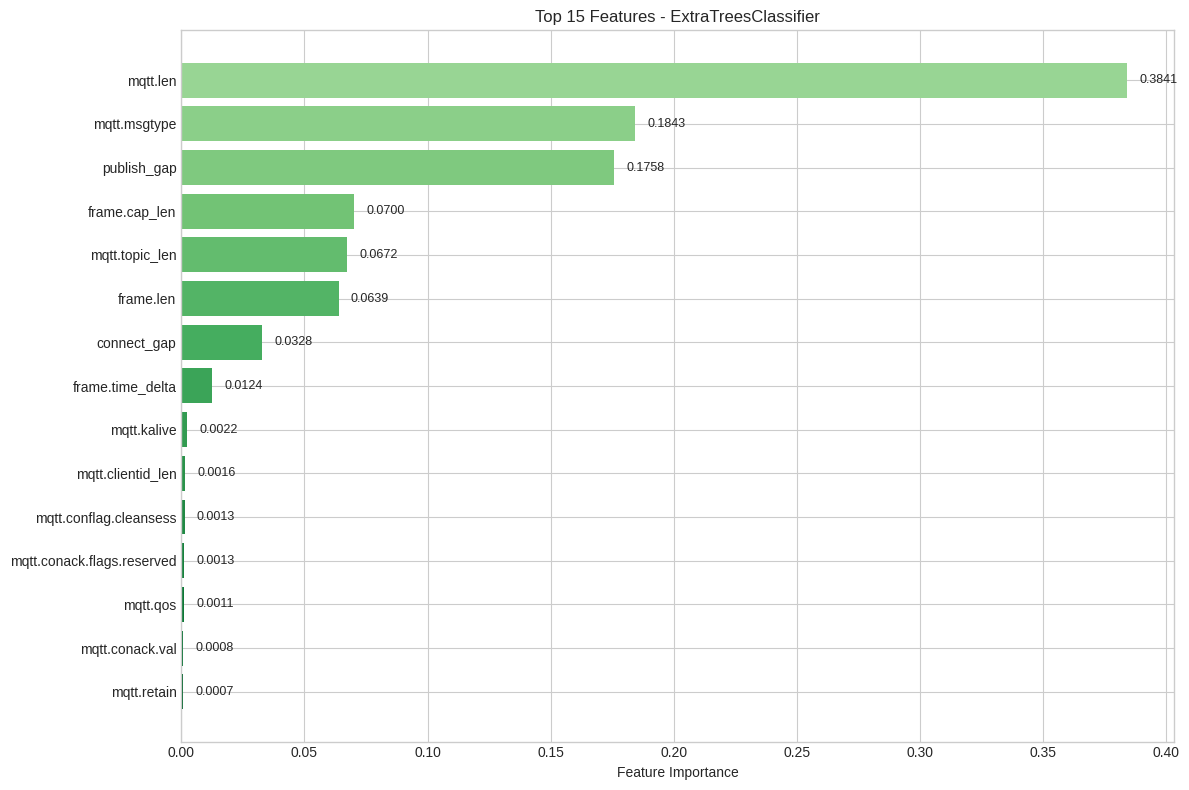


📊 Soma das importâncias (Top 15): 0.9995 (99.9%)


In [20]:
# Visualizar Feature Importance do ExtraTreesClassifier
fig, ax = plt.subplots(figsize=(12, 8))

top_tree = extratree_df.head(K_tree)
colors = plt.cm.Greens(np.linspace(0.4, 0.9, K_tree))

bars = ax.barh(range(K_tree), top_tree['importance'].values, color=colors)
ax.set_yticks(range(K_tree))
ax.set_yticklabels(top_tree['feature'].values)
ax.set_xlabel('Feature Importance')
ax.set_title(f'Top {K_tree} Features - ExtraTreesClassifier', fontsize=12)
ax.invert_yaxis()

# Adicionar valores nas barras
for bar, imp in zip(bars, top_tree['importance'].values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{imp:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Mostrar soma das importâncias do top K
total_importance = top_tree['importance'].sum()
print(f"\n📊 Soma das importâncias (Top {K_tree}): {total_importance:.4f} ({total_importance*100:.1f}%)")

# Comparação do Extra Trees com os outros


In [22]:
# Comparar ExtraTrees com outros métodos
print("📊 COMPARAÇÃO: ExtraTrees vs Outros Métodos")
print("=" * 60)

set_extratree = set(extratree_selected)

# Features em comum com outros métodos
common_tree_mrmr = set_extratree & set_mrmr if selected_features else set()
common_tree_fisher = set_extratree & set_fisher
common_tree_pearson = set_extratree & set_pearson
common_all_4 = set_extratree & set_mrmr & set_fisher & set_pearson if selected_features else set()

print(f"\n🌳 ExtraTrees selecionou: {len(set_extratree)} features")
print(f"\n📌 Features em comum:")
print(f"   ExtraTrees ∩ mRMR: {len(common_tree_mrmr)}")
print(f"   ExtraTrees ∩ Fisher: {len(common_tree_fisher)}")
print(f"   ExtraTrees ∩ Pearson: {len(common_tree_pearson)}")
print(f"   Todos os 4 métodos: {len(common_all_4)}")

if common_all_4:
    print(f"\n✅ Features selecionadas por TODOS os métodos:")
    for f in common_all_4:
        print(f"   - {f}")

📊 COMPARAÇÃO: ExtraTrees vs Outros Métodos

🌳 ExtraTrees selecionou: 15 features

📌 Features em comum:
   ExtraTrees ∩ mRMR: 14
   ExtraTrees ∩ Fisher: 13
   ExtraTrees ∩ Pearson: 13
   Todos os 4 métodos: 13

✅ Features selecionadas por TODOS os métodos:
   - mqtt.conflag.cleansess
   - mqtt.msgtype
   - mqtt.topic_len
   - mqtt.retain
   - publish_gap
   - mqtt.len
   - frame.cap_len
   - mqtt.clientid_len
   - mqtt.conack.flags.reserved
   - mqtt.kalive
   - mqtt.conack.val
   - mqtt.qos
   - frame.len


In [23]:
# Validar ExtraTrees: treinar modelo apenas com features selecionadas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Modelo com features do ExtraTrees
X_train_tree = X_train[extratree_selected]
X_test_tree = X_test[extratree_selected]

print(f"📊 Treinando modelo com {len(extratree_selected)} features ExtraTrees...")
rf_tree = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_tree.fit(X_train_tree, y_train)
acc_tree = accuracy_score(y_test, rf_tree.predict(X_test_tree))

print(f"\n{'='*50}")
print(f"📈 VALIDAÇÃO - ExtraTrees Feature Selection")
print(f"{'='*50}")
print(f"🔹 Features ExtraTrees ({len(extratree_selected)}): Acurácia = {acc_tree:.4f}")
print(f"{'='*50}")

📊 Treinando modelo com 15 features ExtraTrees...

📈 VALIDAÇÃO - ExtraTrees Feature Selection
🔹 Features ExtraTrees (15): Acurácia = 0.9987


# Seleção via LinearSVC


In [35]:
#Normalizar dados 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Treinando LinearSVC para importancia de features")

svc = LinearSVC(C=0.1, penalty='l1', dual=False, max_iter=5000, random_state=42)
svc.fit(X_scaled, y)

#Obter coeficientes 
if len(svc.coef_.shape) > 1:
    #Multiclasse: media dos coeficientes absolutos
    coef_importance = np.mean(np.abs(svc.coef_), axis=0)
else :
    coef_importance = np.abs(svc.coef_[0])

# Montar o data frame com os resultados
svc_df = pd.DataFrame({
    'feature' : X.columns,
    'importance': coef_importance
}).sort_values('importance', ascending=False)

#Selecionar top K features
K_svc = 15

print(f"\n Top {K_svc} Features selecionadas  por LinearSVC:")
for i, (_, row) in enumerate(svc_df.head(K_svc).iterrows(), 1):
    print(f"  {i:2d}. {row['feature']}: {row['importance']:.4f}")

Treinando LinearSVC para importancia de features

 Top 15 Features selecionadas  por LinearSVC:
   1. publish_gap: 10.1183
   2. mqtt.len: 6.6288
   3. mqtt.retain: 2.6279
   4. frame.len: 0.8684
   5. mqtt.clientid_len: 0.1915
   6. mqtt.kalive: 0.1819
   7. mqtt.conflag.cleansess: 0.1126
   8. frame.time_delta: 0.0829
   9. frame.cap_len: 0.0812
  10. mqtt.qos: 0.0531
  11. mqtt.msgtype: 0.0292
  12. connect_gap: 0.0179
  13. mqtt.conack.flags.reserved: 0.0106
  14. mqtt.conflag.uname: 0.0000
  15. mqtt.conflag.retain: 0.0000



#### Para C = 0.1

Treinando LinearSVC para importancia de features
iteracoes: 5000

 Top 15 Features selecionadas  por LinearSVC:
iteracoes: 50000
   1. publish_gap: 10.1183
   2. mqtt.len: 6.6288
   3. mqtt.retain: 2.6279
   4. frame.len: 0.8684
   5. mqtt.clientid_len: 0.1915
   6. mqtt.kalive: 0.1819
   7. mqtt.conflag.cleansess: 0.1126
   8. frame.time_delta: 0.0829
   9. frame.cap_len: 0.0812
  10. mqtt.qos: 0.0531
  11. mqtt.msgtype: 0.0292
  12. connect_gap: 0.0179
  13. mqtt.conack.flags.reserved: 0.0106
  14. mqtt.conflag.uname: 0.0000
  15. mqtt.conflag.retain: 0.0000


Treinando LinearSVC para importancia de features

 Top 15 Features selecionadas  por LinearSVC:
   1. publish_gap: 10.1183
   2. mqtt.len: 6.6288
   3. mqtt.retain: 2.6279
   4. frame.len: 0.8684
   5. mqtt.clientid_len: 0.1915
   6. mqtt.kalive: 0.1819
   7. mqtt.conflag.cleansess: 0.1126
   8. frame.time_delta: 0.0829
   9. frame.cap_len: 0.0812
  10. mqtt.qos: 0.0531
  11. mqtt.msgtype: 0.0292
  12. connect_gap: 0.0179
  13. mqtt.conack.flags.reserved: 0.0106
  14. mqtt.conflag.uname: 0.0000
  15. mqtt.conflag.retain: 0.0000


#### Para c = 0.01

Treinando LinearSVC para importancia de features
 ITERACOES = 50000
 Top 15 Features selecionadas  por LinearSVC:
   1. publish_gap: 7.8773
   2. mqtt.len: 4.4757
   3. mqtt.retain: 1.2058
   4. mqtt.conack.flags.reserved: 0.9581
   5. frame.len: 0.5415
   6. frame.cap_len: 0.1385
   7. mqtt.conflag.cleansess: 0.0971
   8. frame.time_delta: 0.0680
   9. mqtt.msgtype: 0.0388
  10. mqtt.topic_len: 0.0275
  11. connect_gap: 0.0148
  12. mqtt.clientid_len: 0.0000
  13. mqtt.conack.flags.sp: 0.0000
  14. mqtt.conflag.uname: 0.0000
  15. mqtt.conflag.retain: 0.0000


Treinando LinearSVC para importancia de features
  iTERACOERS: 5000
 Top 15 Features selecionadas  por LinearSVC:
   1. publish_gap: 7.8773
   2. mqtt.len: 4.4757
   3. mqtt.retain: 1.2058
   4. mqtt.conack.flags.reserved: 0.9581
   5. frame.len: 0.5415
   6. frame.cap_len: 0.1385
   7. mqtt.conflag.cleansess: 0.0971
   8. frame.time_delta: 0.0680
   9. mqtt.msgtype: 0.0388
  10. mqtt.topic_len: 0.0275
  11. connect_gap: 0.0148
  12. mqtt.clientid_len: 0.0000
  13. mqtt.conack.flags.sp: 0.0000
  14. mqtt.conflag.uname: 0.0000
  15. mqtt.conflag.retain: 0.0000

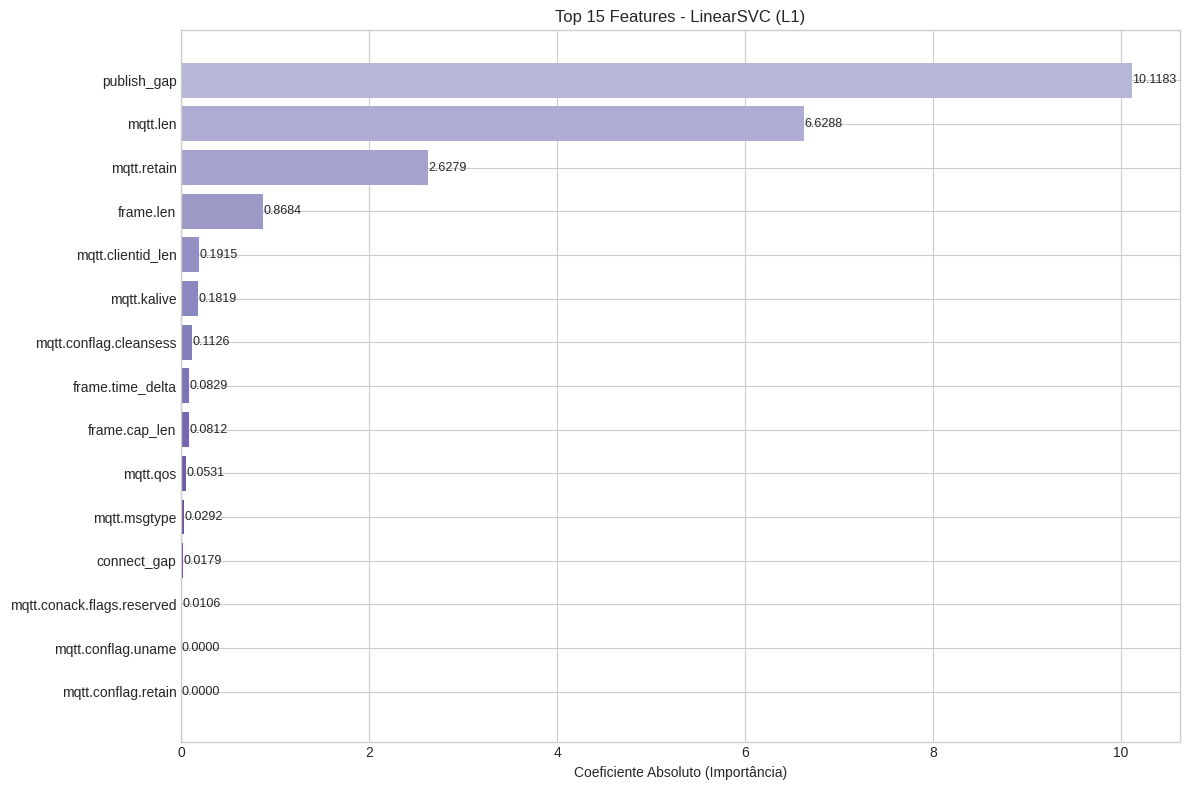


📊 Features com coeficiente não-zero: 13/29


In [36]:
# Visualizar Feature Importance do LinearSVC
fig, ax = plt.subplots(figsize=(12, 8))

top_svc = svc_df.head(K_svc)
colors = plt.cm.Purples(np.linspace(0.4, 0.9, K_svc))

bars = ax.barh(range(K_svc), top_svc['importance'].values, color=colors)
ax.set_yticks(range(K_svc))
ax.set_yticklabels(top_svc['feature'].values)
ax.set_xlabel('Coeficiente Absoluto (Importância)')
ax.set_title(f'Top {K_svc} Features - LinearSVC (L1)', fontsize=12)
ax.invert_yaxis()

# Adicionar valores nas barras
for bar, imp in zip(bars, top_svc['importance'].values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{imp:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Contar features com coeficiente não-zero
non_zero = (svc_df['importance'] > 0).sum()
print(f"\n📊 Features com coeficiente não-zero: {non_zero}/{len(svc_df)}")

In [42]:
# Validar LinearSVC: treinar modelo apenas com features selecionadas
svc_selected = svc_df.head(K_svc)['feature'].tolist()
X_train_svc = X_train[svc_selected]
X_test_svc = X_test[svc_selected]

print(f"📊 Treinando modelo com {len(svc_selected)} features LinearSVC...")
rf_svc = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_svc.fit(X_train_svc, y_train)
acc_svc = accuracy_score(y_test, rf_svc.predict(X_test_svc))

print(f"\n{'='*50}")
print(f"📈 VALIDAÇÃO - LinearSVC Feature Selection")
print(f"{'='*50}")
print(f"🔹 Features LinearSVC ({len(svc_selected)}): Acurácia = {acc_svc:.4f}")
print(f"{'='*50}")

📊 Treinando modelo com 15 features LinearSVC...

📈 VALIDAÇÃO - LinearSVC Feature Selection
🔹 Features LinearSVC (15): Acurácia = 0.9988
